# **DELIMITY AND DRAWING OF ZONES OF THE ARGENTINIAN ID CARD**

In this notebook, will be delimity and drawing the mainly zones of the argentinian ID Card in our templates (front and back) for our two types of IDs cards:

* DNI -> Is the current type of document in Argentina.
* CARD -> Is the old type od document in Argentina.

This process is necesary to in a later step we can generate our sinthetic examples of Argentinian ID Cards.

So, the input in this process are our templates. And the output is a *json* file with the coords of our elements according to its type.

## **Libraries**

In [ ]:
from typing import List
import os
import cv2 
import matplotlib.pyplot as plt
import numpy as np  
import json

BASE_TEMPLATE_DIR = os.getenv('BASE_DIR') + '/data/templates'
TEMPLATES = os.listdir(BASE_TEMPLATE_DIR)
FRONTS = [template for template in TEMPLATES if template.startswith('front')]
BACKS = [template for template in TEMPLATES if template.startswith('back')]
  
DATA = {}

print(f"Numpy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Numpy version: 2.3.5
OpenCV version: 4.10.0
Matplotlib version: 3.11.0


* Functions to draw and visualize the zone delimited

In [34]:
def draw_zones_on_template(img_path: str, zones: List, relative: bool=False) -> None:
    if img_path is None or not os.path.exists(img_path):
        raise ValueError(f"Invalid image path: {img_path}")
    
    img = cv2.imread(filename=img_path)
    if img is None:
        raise ValueError(f"Failed to read image from path: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if zones is not None and len(zones) > 0:
        for zone in zones:
            if relative:
                h, w, _ = img.shape
                zone = [(int(b[0] * w), int(b[1] * h)) for b in zone]
            cv2.rectangle(img,
            pt1=zone[0],
            pt2=zone[1],
            color=(0, 0, 255),
            thickness=2)

    plt.imshow(img)
    plt.title(f"Template with zones: {os.path.basename(img_path)}")
    plt.show()

def to_relative(img: np.ndarray, zones: tuple) :
    h, w, _ = img.shape
    # print(f"Image dimensions: width={w}, height={h}")
    relative_bbox = [(b[0] / w, b[1] / h) for b in zones]
    # print(f"Relative bounding boxes: {relative_bbox}")
    return relative_bbox 

### **Front of DNI Document type**

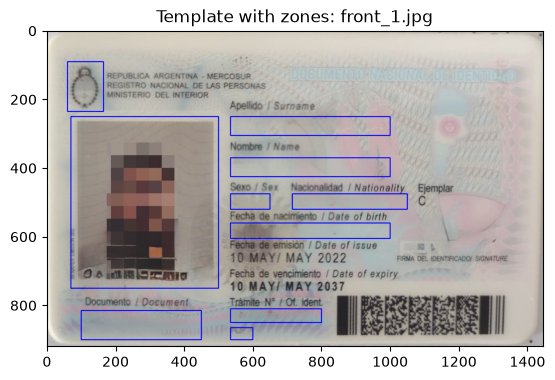

In [50]:
front_template_path = os.path.join(BASE_TEMPLATE_DIR, FRONTS[0])

PICTURE_COORD = [(70, 250), (500, 750)]
SHIELD_COORD = [(60, 90), (165, 235)]
FIRST_NAME_COORD = [(535, 370), (1000, 425)]
LAST_NAME_COORD = [(535, 250), (1000, 305)]
DOCUMENT_NUMBER_COORD = [(100, 815), (450, 900)]
SEX_COORD = [(535, 475), (650, 520) ]
NATIONALITY_COORD = [(715, 475), (1050, 520)]
BIRTH_DATE_COORD = [(535, 560), (1000, 605)]
NRO_TRAMITE_COORD = [(535, 810), (800, 850)]
OFFICE_CODE_COORD = [(535, 865), (600, 900)]

DNI_FRONT_ZONES = [
    PICTURE_COORD,
    SHIELD_COORD,
    FIRST_NAME_COORD,
    LAST_NAME_COORD,
    DOCUMENT_NUMBER_COORD,
    SEX_COORD,
    NATIONALITY_COORD,
    BIRTH_DATE_COORD,
    OFFICE_CODE_COORD,
    NRO_TRAMITE_COORD
]

draw_zones_on_template(img_path=front_template_path, zones=DNI_FRONT_ZONES)

* Now complete the data with the relatives coords for each element of document.

In [51]:
front_template_img = cv2.imread(filename=front_template_path)

DATA['dni'] = {
    'front': {
        'PICTURE_COORD': to_relative(img=front_template_img, zones=PICTURE_COORD),
        'SHIELD_COORD': to_relative(img=front_template_img, zones=SHIELD_COORD),
        'FIRST_NAME_COORD': to_relative(img=front_template_img, zones=FIRST_NAME_COORD),
        'LAST_NAME_COORD': to_relative(img=front_template_img, zones=LAST_NAME_COORD),
        'DOCUMENT_NUMBER_COORD': to_relative(img=front_template_img, zones=DOCUMENT_NUMBER_COORD),
        'SEX_COORD': to_relative(img=front_template_img, zones=SEX_COORD),
        'NATIONALITY_COORD': to_relative(img=front_template_img, zones=NATIONALITY_COORD),
        'BIRTH_DATE_COORD': to_relative(img=front_template_img, zones=BIRTH_DATE_COORD),
        'NRO_TRAMITE_COORD': to_relative(img=front_template_img, zones=NRO_TRAMITE_COORD),
        'OFFICE_CODE_COORD': to_relative(img=front_template_img, zones=OFFICE_CODE_COORD)
    },
    'back': {}
}

DATA

{'dni': {'front': {'PICTURE_COORD': [(0.04844290657439446, 0.2717391304347826),
    (0.3460207612456747, 0.8152173913043478)],
   'SHIELD_COORD': [(0.04152249134948097, 0.09782608695652174),
    (0.11418685121107267, 0.2554347826086957)],
   'FIRST_NAME_COORD': [(0.370242214532872, 0.40217391304347827),
    (0.6920415224913494, 0.46195652173913043)],
   'LAST_NAME_COORD': [(0.370242214532872, 0.2717391304347826),
    (0.6920415224913494, 0.33152173913043476)],
   'DOCUMENT_NUMBER_COORD': [(0.06920415224913495, 0.8858695652173914),
    (0.31141868512110726, 0.9782608695652174)],
   'SEX_COORD': [(0.370242214532872, 0.5163043478260869),
    (0.44982698961937717, 0.5652173913043478)],
   'NATIONALITY_COORD': [(0.49480968858131485, 0.5163043478260869),
    (0.726643598615917, 0.5652173913043478)],
   'BIRTH_DATE_COORD': [(0.370242214532872, 0.6086956521739131),
    (0.6920415224913494, 0.657608695652174)],
   'NRO_TRAMITE_COORD': [(0.370242214532872, 0.8804347826086957),
    (0.55363321799

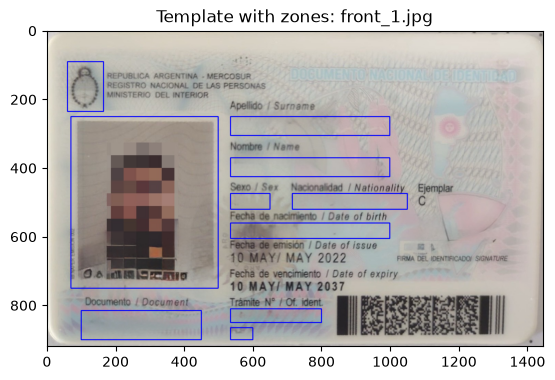

In [52]:
ELEMENTS = [value for _, value in DATA['dni']['front'].items()] # type: ignore
draw_zones_on_template(img_path=front_template_path, zones=ELEMENTS, relative=True)

### **Back of DNI Document Type**

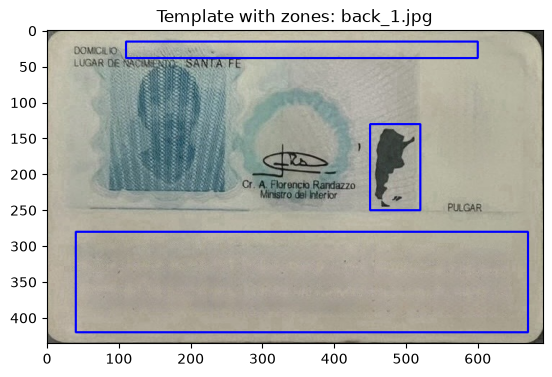

In [53]:
back_template_path = os.path.join(BASE_TEMPLATE_DIR, BACKS[1])

ADDRESS_COORD = [(110, 15), (600, 38)]
MRZ_COORD = [(40, 280), (670, 420)]
COUNTRY_COORD = [(450, 130), (520, 250)]

draw_zones_on_template(img_path=back_template_path, zones=[ADDRESS_COORD, MRZ_COORD, COUNTRY_COORD])

* Now complete the data with the relatives coords for each element of document.

In [54]:
img = cv2.imread(filename=back_template_path)

DATA['dni']['back'] = {
    'ADDRESS_COORD': to_relative(img=img, zones=ADDRESS_COORD),
    'MRZ_COORD': to_relative(img=img, zones=MRZ_COORD),
    'COUNTRY_COORD': to_relative(img=img, zones=COUNTRY_COORD)
}

DATA

{'dni': {'front': {'PICTURE_COORD': [(0.04844290657439446, 0.2717391304347826),
    (0.3460207612456747, 0.8152173913043478)],
   'SHIELD_COORD': [(0.04152249134948097, 0.09782608695652174),
    (0.11418685121107267, 0.2554347826086957)],
   'FIRST_NAME_COORD': [(0.370242214532872, 0.40217391304347827),
    (0.6920415224913494, 0.46195652173913043)],
   'LAST_NAME_COORD': [(0.370242214532872, 0.2717391304347826),
    (0.6920415224913494, 0.33152173913043476)],
   'DOCUMENT_NUMBER_COORD': [(0.06920415224913495, 0.8858695652173914),
    (0.31141868512110726, 0.9782608695652174)],
   'SEX_COORD': [(0.370242214532872, 0.5163043478260869),
    (0.44982698961937717, 0.5652173913043478)],
   'NATIONALITY_COORD': [(0.49480968858131485, 0.5163043478260869),
    (0.726643598615917, 0.5652173913043478)],
   'BIRTH_DATE_COORD': [(0.370242214532872, 0.6086956521739131),
    (0.6920415224913494, 0.657608695652174)],
   'NRO_TRAMITE_COORD': [(0.370242214532872, 0.8804347826086957),
    (0.55363321799

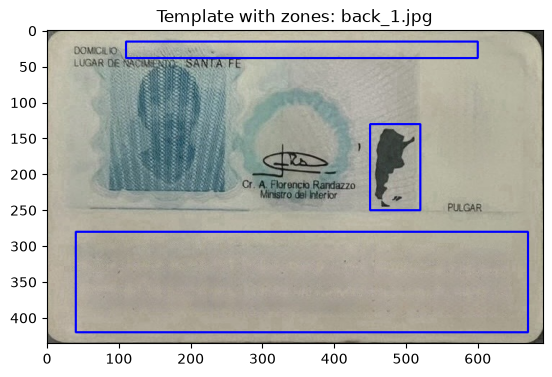

In [55]:
ELEMENTS = [value for _, value in DATA['dni']['back'].items()] # type: ignore
draw_zones_on_template(img_path=back_template_path, zones=ELEMENTS, relative=True)

### **Front of Card Document Type**

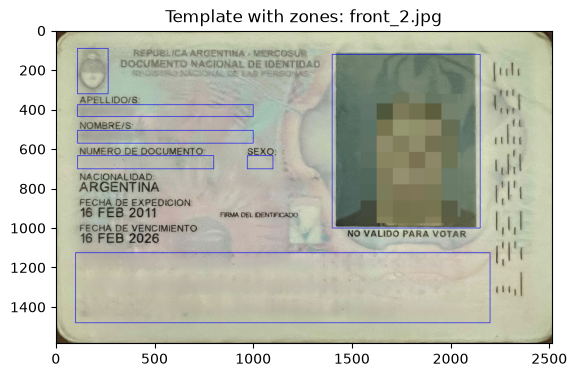

In [56]:
front_template_path = os.path.join(BASE_TEMPLATE_DIR, FRONTS[1])
front_img = cv2.imread(filename=front_template_path)

PICTURE_COORD = [(1400, 120), (2150, 1000)]
SHIELD_COORD = [(110, 90), (265, 320)]
FIRST_NAME_COORD = [(110, 375), (1000, 435)]
LAST_NAME_COORD = [(110, 505), (1000, 570)]
DOCUMENT_NUMBER_COORD = [(110, 633), (800, 700)]
SEX_COORD = [(970, 633), (1100, 700)]
MRZ_COORD = [(100, 1125), (2200, 1480)]

FRONT_ZONES = [
    PICTURE_COORD,
    SHIELD_COORD,
    FIRST_NAME_COORD,
    LAST_NAME_COORD,
    DOCUMENT_NUMBER_COORD,
    SEX_COORD,
    MRZ_COORD
]

draw_zones_on_template(img_path=front_template_path, zones=FRONT_ZONES)

* Now complete the data with the relatives coords for each element of document.

In [57]:
img = cv2.imread(filename=front_template_path)

DATA['card'] = {
    'front': {
        'PICTURE_COORD': to_relative(img=img, zones=PICTURE_COORD),
        'SHIELD_COORD': to_relative(img=img, zones=SHIELD_COORD),
        'FIRST_NAME_COORD': to_relative(img=img, zones=FIRST_NAME_COORD),
        'LAST_NAME_COORD': to_relative(img=img, zones=LAST_NAME_COORD),
        'DOCUMENT_NUMBER_COORD': to_relative(img=img, zones=DOCUMENT_NUMBER_COORD),
        'SEX_COORD': to_relative(img=img, zones=SEX_COORD),
        'MRZ_COORD': to_relative(img=img, zones=MRZ_COORD)
    },
    'back': {}
}

DATA

{'dni': {'front': {'PICTURE_COORD': [(0.04844290657439446, 0.2717391304347826),
    (0.3460207612456747, 0.8152173913043478)],
   'SHIELD_COORD': [(0.04152249134948097, 0.09782608695652174),
    (0.11418685121107267, 0.2554347826086957)],
   'FIRST_NAME_COORD': [(0.370242214532872, 0.40217391304347827),
    (0.6920415224913494, 0.46195652173913043)],
   'LAST_NAME_COORD': [(0.370242214532872, 0.2717391304347826),
    (0.6920415224913494, 0.33152173913043476)],
   'DOCUMENT_NUMBER_COORD': [(0.06920415224913495, 0.8858695652173914),
    (0.31141868512110726, 0.9782608695652174)],
   'SEX_COORD': [(0.370242214532872, 0.5163043478260869),
    (0.44982698961937717, 0.5652173913043478)],
   'NATIONALITY_COORD': [(0.49480968858131485, 0.5163043478260869),
    (0.726643598615917, 0.5652173913043478)],
   'BIRTH_DATE_COORD': [(0.370242214532872, 0.6086956521739131),
    (0.6920415224913494, 0.657608695652174)],
   'NRO_TRAMITE_COORD': [(0.370242214532872, 0.8804347826086957),
    (0.55363321799

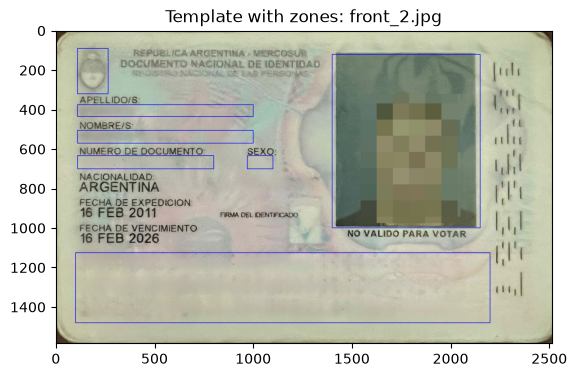

In [58]:
ELEMENTS = [value for _, value in DATA['card']['front'].items()] # type: ignore
draw_zones_on_template(img_path=front_template_path, zones=ELEMENTS, relative=True)

### **Back of Card Document Type**

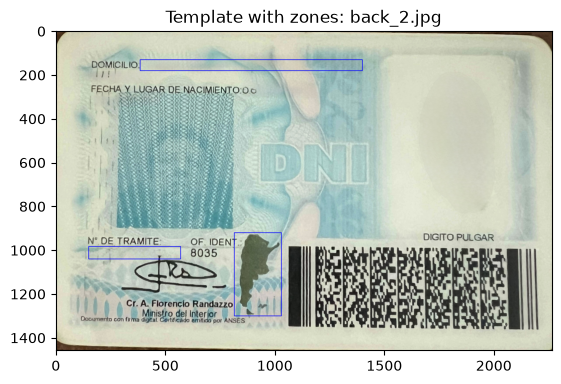

In [59]:
back_template_path = os.path.join(BASE_TEMPLATE_DIR, BACKS[0])
back_img = cv2.imread(filename=back_template_path)

ADDRESS_COORD = [(385, 130), (1400, 180)]
NRO_TRAMITE_COORD = [(150, 983), (570, 1040)]
COUNTRY_COORD = [(815, 920), (1030, 1300)]

draw_zones_on_template(img_path=back_template_path, zones=[ADDRESS_COORD, NRO_TRAMITE_COORD, COUNTRY_COORD])

* Now complete the data with the relatives coords for each element of document.

In [60]:
img = cv2.imread(filename=back_template_path)

DATA['card']['back'] = {
    'ADDRESS_COORD': to_relative(img=img, zones=ADDRESS_COORD),
    'NRO_TRAMITE_COORD': to_relative(img=img, zones=NRO_TRAMITE_COORD),
    'COUNTRY_COORD': to_relative(img=img, zones=COUNTRY_COORD)
}

DATA

{'dni': {'front': {'PICTURE_COORD': [(0.04844290657439446, 0.2717391304347826),
    (0.3460207612456747, 0.8152173913043478)],
   'SHIELD_COORD': [(0.04152249134948097, 0.09782608695652174),
    (0.11418685121107267, 0.2554347826086957)],
   'FIRST_NAME_COORD': [(0.370242214532872, 0.40217391304347827),
    (0.6920415224913494, 0.46195652173913043)],
   'LAST_NAME_COORD': [(0.370242214532872, 0.2717391304347826),
    (0.6920415224913494, 0.33152173913043476)],
   'DOCUMENT_NUMBER_COORD': [(0.06920415224913495, 0.8858695652173914),
    (0.31141868512110726, 0.9782608695652174)],
   'SEX_COORD': [(0.370242214532872, 0.5163043478260869),
    (0.44982698961937717, 0.5652173913043478)],
   'NATIONALITY_COORD': [(0.49480968858131485, 0.5163043478260869),
    (0.726643598615917, 0.5652173913043478)],
   'BIRTH_DATE_COORD': [(0.370242214532872, 0.6086956521739131),
    (0.6920415224913494, 0.657608695652174)],
   'NRO_TRAMITE_COORD': [(0.370242214532872, 0.8804347826086957),
    (0.55363321799

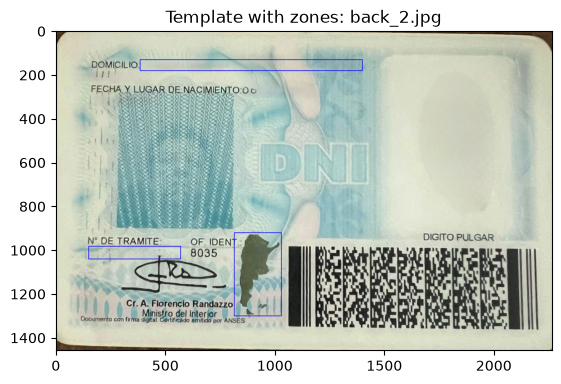

In [61]:
ELEMENTS = [value for _, value in DATA['card']['back'].items()] # type: ignore
draw_zones_on_template(img_path=back_template_path, zones=ELEMENTS, relative=True)

* Now save our dictionary as a json file

In [62]:
with open("./config/coords_data.json", "w") as file:
    json.dump(DATA, file)